# Imports + Helper Functions

In [1]:
from equi7grid_lite import Equi7Grid
import matplotlib.pyplot as plt
import geopandas as gpd
from sentle import sentle
from rasterio.crs import CRS


In [2]:
# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [3]:
def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    #gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Convert square meters to square kilometers
    gdf['areakm2'] = gdf_projected['area_meters'] / 1e6
    
    
    # Return the GeoDataFrame with the new area columns
    return gdf

# Equi7Grid

In [10]:
grid_system = Equi7Grid(min_grid_size=10240) # 1370 gridsize 
grid_system

Equi7Grid(min_grid_size=10240)
----------------
levels: 0, 1, ... , 5, 6
zones: AN, NA, OC, SA, AF, EU, AS
min_grid_size: 10240 meters
max_grid_size: 1310720 meters

In [4]:
grid_system = Equi7Grid(min_grid_size=5120) # 1370 gridsize 
grid_system

Equi7Grid(min_grid_size=5120)
----------------
levels: 0, 1, ... , 6, 7
zones: AN, NA, OC, SA, AF, EU, AS
min_grid_size: 5120 meters
max_grid_size: 1310720 meters

,zone,level,land,geometry
0,NA,Z0,True,"POLYGON ((7388160 2672640, 7388160 2677760, 73..."
1,NA,Z0,True,"POLYGON ((7388160 2677760, 7388160 2682880, 73..."
2,NA,Z0,True,"POLYGON ((7388160 2682880, 7388160 2688000, 73..."
3,NA,Z0,True,"POLYGON ((7388160 2688000, 7388160 2693120, 73..."
4,NA,Z0,True,"POLYGON ((7388160 2693120, 7388160 2698240, 73..."
...,...,...,...,...
87513,NA,Z0,True,"POLYGON ((10240000 3322880, 10240000 3328000, ..."
87514,NA,Z0,True,"POLYGON ((10240000 3328000, 10240000 3333120, ..."
87515,NA,Z0,True,"POLYGON ((10240000 3333120, 10240000 3338240, ..."
87516,NA,Z0,True,"POLYGON ((10240000 3338240, 10240000 3343360, ..."


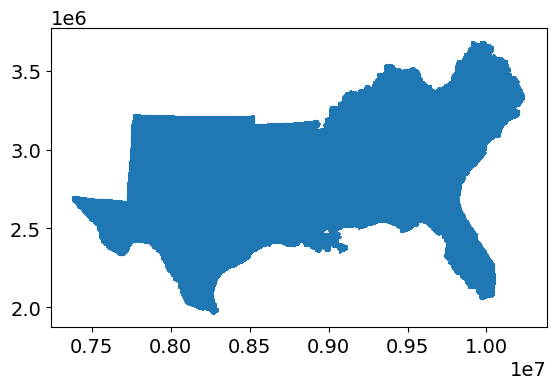

In [5]:
# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[0:1]

# Create a grid of Equi7Grid tiles that cover the bounding box of the POLYGON geometry
grid = grid_system.create_grid(
    level=0,
    zone="NA",
    mask=region # Only include tiles that intersect the polygon   
)
grid.boundary.plot()
grid


In [6]:
grid[0:1]
polygon_length = grid.geometry[0].length
print(f"Length of the perimeter of the first polygon: {polygon_length}")
from shapely.geometry import LineString

# Assuming `grid` is a GeoDataFrame and contains polygons in the 'geometry' column
# Get the boundary of the first polygon
boundary = grid.geometry[0].boundary

# The boundary is a LineString or MultiLineString; convert it to a list of coordinates
boundary_coords = list(boundary.coords)

# Calculate the length of the first edge (side) by computing the distance between the first two points
first_edge_length = LineString([boundary_coords[0], boundary_coords[1]]).length
# Assuming the polygon is a square, calculate the area
area = first_edge_length ** 2

print(f"Length of the first edge: {first_edge_length}")
print(f"Estimated area (assuming square): {area}")
polygon_area = grid.geometry[0].area
print(f"Area of the first polygon: {polygon_area}")

Length of the perimeter of the first polygon: 20480.0
Length of the first edge: 5120.0
Estimated area (assuming square): 26214400.0
Area of the first polygon: 26214400.0


In [7]:
grid_epsg4326 = grid.to_crs(epsg=4326)
grid_epsg4326 = calculate_area(grid_epsg4326)
print(len(grid_epsg4326))
size = grid_epsg4326[0:1]['areakm2'][0]
print(f'Size of Grid: {size} km²')
grid_epsg4326[0:10]

87518
Size of Grid: 31.96555435522392 km²


,zone,level,land,geometry,areakm2
0,NA,Z0,True,"POLYGON ((-106.58309 31.79102, -106.58847 31.8...",31.965554
1,NA,Z0,True,"POLYGON ((-106.58847 31.83682, -106.59385 31.8...",31.963016
2,NA,Z0,True,"POLYGON ((-106.59385 31.88263, -106.59924 31.9...",31.960465
3,NA,Z0,True,"POLYGON ((-106.59924 31.92843, -106.60464 31.9...",31.957902
4,NA,Z0,True,"POLYGON ((-106.60464 31.97423, -106.61006 32.0...",31.955326
5,NA,Z0,True,"POLYGON ((-106.5251 31.75042, -106.53044 31.79...",31.944663
6,NA,Z0,True,"POLYGON ((-106.53044 31.79623, -106.53578 31.8...",31.942149
7,NA,Z0,True,"POLYGON ((-106.53578 31.84204, -106.54114 31.8...",31.939622
8,NA,Z0,True,"POLYGON ((-106.54114 31.88784, -106.5465 31.93...",31.937084
9,NA,Z0,True,"POLYGON ((-106.5465 31.93365, -106.55187 31.97...",31.934533


In [3]:
grid = gpd.read_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/grid.shp")
grid

In [8]:
# Define a POLYGON geometry
#path = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/convex_hulls_refdm.shp'
file_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/overlapping_results/convex_hulls_refdm.shp"
conves = gpd.read_file(file_path)
conves

,USDA_IDX,geometry
0,bark_beetle_2017_24325,"POLYGON ((-86.08953 32.13766, -86.09646 32.138..."
1,bark_beetle_2017_24326,"POLYGON ((-86.01467 32.00506, -86.01698 32.005..."
2,bark_beetle_2017_24327,"POLYGON ((-86.24927 32.05703, -86.24965 32.057..."
3,bark_beetle_2017_24328,"POLYGON ((-86.0878 32.05298, -86.09646 32.0539..."
4,bark_beetle_2017_24329,"POLYGON ((-87.39959 32.86345, -87.40269 32.864..."
...,...,...
16081,wind_2020_55678,"POLYGON ((-93.37887 30.29627, -93.39679 30.297..."
16082,wind_2020_55679,"POLYGON ((-93.19165 30.41396, -93.19858 30.433..."
16083,wind_2020_55694,"POLYGON ((-87.78597 30.43215, -87.78654 30.432..."
16084,wind_2020_55695,"POLYGON ((-87.78578 30.43521, -87.78865 30.436..."


In [9]:
equi7_crs = grid.crs
# Reproject the GeoDataFrame to Equi7Grid
conves_equi7 = conves.to_crs(equi7_crs)
conves_equi7

,USDA_IDX,geometry
0,bark_beetle_2017_24325,"POLYGON ((9359731.391 2739652.4, 9359059.683 2..."
1,bark_beetle_2017_24326,"POLYGON ((9368767.212 2726063.092, 9368543.852..."
2,bark_beetle_2017_24327,"POLYGON ((9345625.074 2728579.964, 9345585.621..."
3,bark_beetle_2017_24328,"POLYGON ((9361100.207 2730338.409, 9360259.673..."
4,bark_beetle_2017_24329,"POLYGON ((9225486.648 2802821.392, 9225185.786..."
...,...,...
16081,wind_2020_55678,"POLYGON ((8670615.184 2467493.636, 8668846.462..."
16082,wind_2020_55679,"POLYGON ((8688421.614 2481493.835, 8687637.149..."
16083,wind_2020_55694,"POLYGON ((9218158.215 2529719.986, 9218099.941..."
16084,wind_2020_55695,"POLYGON ((9218140.633 2530059.839, 9217847.011..."


<Axes: >

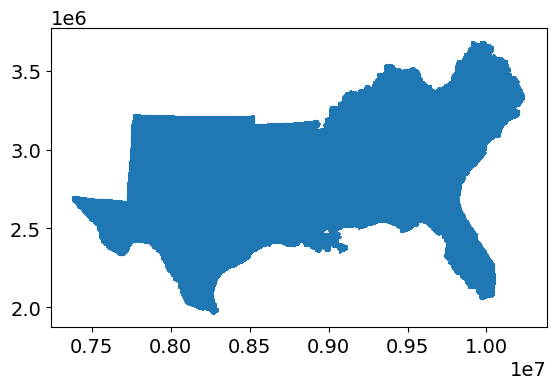

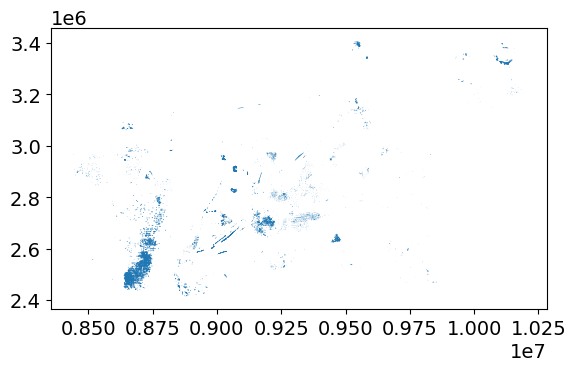

In [10]:
grid.boundary.plot()
#grid_epsg4326.boundary.plot()
conves_equi7.plot()

In [11]:
intersected_gdf = gpd.sjoin(grid_epsg4326, conves, how='inner', predicate='intersects')
intersected_gdf = intersected_gdf.reset_index()
intersected_gdf = intersected_gdf.drop(columns=['index_right','USDA_IDX','areakm2','level','land','zone'])
intersected_gdf = intersected_gdf.drop_duplicates()
intersected_gdf = intersected_gdf.reset_index()
intersected_gdf = intersected_gdf.drop(columns=['level_0','index'])
intersected_gdf

,geometry
0,"POLYGON ((-95.59395 34.34417, -95.59274 34.390..."
1,"POLYGON ((-95.58059 34.85167, -95.57936 34.897..."
2,"POLYGON ((-95.53919 34.34304, -95.53795 34.389..."
3,"POLYGON ((-95.49076 34.11119, -95.4895 34.1573..."
4,"POLYGON ((-95.48443 34.34188, -95.48316 34.388..."
...,...
3992,"POLYGON ((-76.63889 34.91821, -76.62566 34.962..."
3993,"POLYGON ((-76.16212 36.4611, -76.14807 36.5051..."
3994,"POLYGON ((-76.61189 34.81785, -76.59868 34.861..."
3995,"POLYGON ((-76.53165 34.70537, -76.51843 34.749..."


In [12]:
intersected_gdf_equi7 = gpd.sjoin(grid, conves_equi7, how='inner', predicate='intersects')
intersected_gdf_equi7 = intersected_gdf_equi7.reset_index()
intersected_gdf_equi7 = intersected_gdf_equi7.drop(columns=['index_right','USDA_IDX','level','land','zone'])
intersected_gdf_equi7 = intersected_gdf_equi7.drop_duplicates()
intersected_gdf_equi7 = intersected_gdf_equi7.reset_index()
intersected_gdf_equi7 = intersected_gdf_equi7.drop(columns=['level_0','index'])
intersected_gdf_equi7

,geometry
0,"POLYGON ((8442880 2908160, 8442880 2913280, 84..."
1,"POLYGON ((8442880 2964480, 8442880 2969600, 84..."
2,"POLYGON ((8448000 2908160, 8448000 2913280, 84..."
3,"POLYGON ((8453120 2882560, 8453120 2887680, 84..."
4,"POLYGON ((8453120 2908160, 8453120 2913280, 84..."
...,...
3992,"POLYGON ((10178560 3225600, 10178560 3230720, ..."
3993,"POLYGON ((10178560 3404800, 10178560 3409920, ..."
3994,"POLYGON ((10183680 3215360, 10183680 3220480, ..."
3995,"POLYGON ((10193920 3205120, 10193920 3210240, ..."


3997


<Axes: >

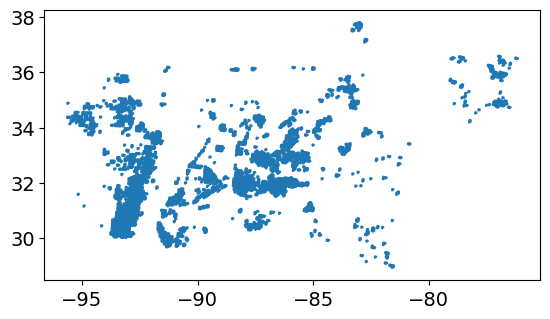

In [13]:
print(len(intersected_gdf))
intersected_gdf.boundary.plot()

3997


<Axes: >

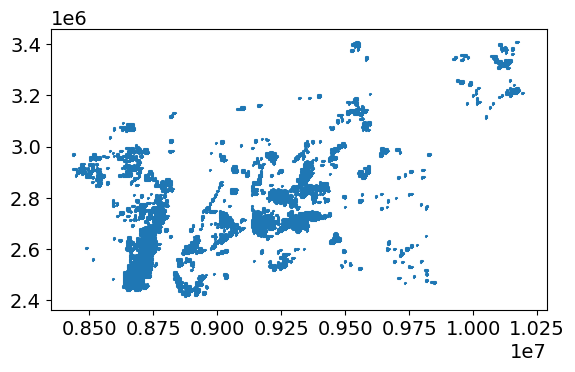

In [14]:
print(len(intersected_gdf_equi7))
intersected_gdf_equi7.boundary.plot()

In [23]:
meter_inter_gdf = intersected_gdf_equi7.to_crs("EPSG:32633")
meter_inter_gdf

,geometry
0,"POLYGON ((-6054045.032 13024007.123, -6047426...."
1,"POLYGON ((-5981403.758 12973972.81, -5974817.2..."
2,"POLYGON ((-6058579.531 13017500.191, -6051954...."
3,"POLYGON ((-6096314.39 13033994.482, -6089668.1..."
4,"POLYGON ((-6063112.41 13010986.893, -6056480.7..."
...,...
3992,"POLYGON ((-6864347.684 10258119.362, -6855959...."
3993,"POLYGON ((-6575719.397 10172435.773, -6567618...."
3994,"POLYGON ((-6883898.732 10254782.869, -6875488...."
3995,"POLYGON ((-6906241.501 10243023.697, -6897804...."


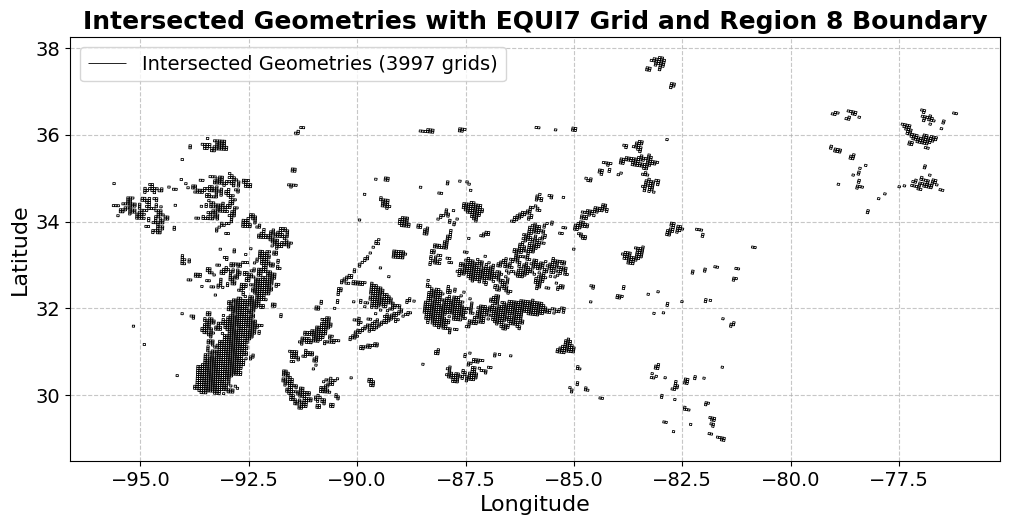

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load your GeoDataFrames
# intersected_gdf = gpd.read_file('path_to_your_intersected_gdf.shp')
# country = gpd.read_file('path_to_your_country_shapefile.shp')

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8
#region = region.to_crs(equi7_crs)
# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
intersected_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)

# Plot the boundary of region 8
#region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({len(intersected_gdf)} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


In [16]:
grid.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/grid_10_res.shp")
grid_epsg4326.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/grid_epsg4326_10_res.shp")
intersected_gdf_equi7.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/intersected_grid_espg_equi7_10_res.shp")

# Sentle Download

In [3]:
intersected_gdf_equi7 = gpd.read_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/intersected_grid_espg_equi7_10_res.shp")
intersected_gdf_equi7

,FID,geometry
0,0,"POLYGON ((8442880 2908160, 8437760 2908160, 84..."
1,1,"POLYGON ((8442880 2964480, 8437760 2964480, 84..."
2,2,"POLYGON ((8448000 2908160, 8442880 2908160, 84..."
3,3,"POLYGON ((8453120 2882560, 8448000 2882560, 84..."
4,4,"POLYGON ((8453120 2908160, 8448000 2908160, 84..."
...,...,...
3992,3992,"POLYGON ((10178560 3225600, 10173440 3225600, ..."
3993,3993,"POLYGON ((10178560 3404800, 10173440 3404800, ..."
3994,3994,"POLYGON ((10183680 3215360, 10178560 3215360, ..."
3995,3995,"POLYGON ((10193920 3205120, 10188800 3205120, ..."


In [4]:
bounds = intersected_gdf_equi7[0:1].geometry.iloc[0].bounds
print(bounds)
bound_left = int(bounds[0])
bound_bottom = int(bounds[1])
bound_right = int(bounds[2])
bound_top = int(bounds[3])
print(bound_top)
equi7_crs = intersected_gdf_equi7.crs


(8437760.0, 2908160.0, 8442880.0, 2913280.0)
2913280


In [5]:
equi7_crs = intersected_gdf_equi7.crs
da = sentle.process(
    target_crs=equi7_crs, #CRS.from_string("EPSG:27705"),
    bound_left=bound_left,
    bound_bottom=bound_bottom,
    bound_right=bound_right,
    bound_top=bound_top,
    datetime="2015-01-01/2024-07-31",
    target_resolution=10,
    S2_mask_snow=True,
    S2_cloud_classification=True,
    S2_cloud_classification_device="cpu",
    S1_assets=["vv", "vh"],
    S2_apply_snow_mask=True,
    S2_apply_cloud_mask=True,
    time_composite_freq="7d",
    num_workers=1,
)
da

Setting up dask cluster with 1 workers.
Dask client dashboard link: http://127.0.0.1:9988/status


<xarray.DataArray 'full_like-8481cff5c53b6b46ee85916a22fc75a8' (time: 462,
                                                                band: 14,
                                                                y: 512, x: 512)> Size: 7GB
dask.array<<this-array>-process_ptile, shape=(462, 14, 512, 512), dtype=float32, chunksize=(1, 12, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) <U3 168B 'B01' 'B02' 'B03' 'B04' ... 'B11' 'B12' 'vv' 'vh'
  * x        (x) float32 2kB 8.438e+06 8.438e+06 ... 8.443e+06 8.443e+06
  * y        (y) float32 2kB 2.913e+06 2.913e+06 ... 2.908e+06 2.908e+06
  * time     (time) datetime64[ns] 4kB 2024-08-01 2024-07-25 ... 2015-03-12

In [7]:
sentle.save_as_zarr(da, path="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/grids/1_zarr_minicube.zarr")

Task exception was never retrieved
future: <Task finished name='Task-8449' coro=<Client._gather.<locals>.wait() done, defined at /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/equi7/lib/python3.11/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/equi7/lib/python3.11/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-8274' coro=<Client._gather.<locals>.wait() done, defined at /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/equi7/lib/python3.11/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/equi7/lib/python3.11/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future:

KeyboardInterrupt: 

In [ ]:
da.compute()

<xarray.DataArray 'full_like-8481cff5c53b6b46ee85916a22fc75a8' (y: 512, x: 512)> Size: 1MB
dask.array<getitem, shape=(512, 512), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Coordinates:
    band     <U3 12B 'B8A'
  * x        (x) float32 2kB 8.438e+06 8.438e+06 ... 8.443e+06 8.443e+06
  * y        (y) float32 2kB 2.913e+06 2.913e+06 ... 2.908e+06 2.908e+06
    time     datetime64[ns] 8B 2024-06-06

2024-08-22 15:06:54,960 - distributed.client - ERROR - Failed to reconnect to scheduler after 1.00 seconds, closing client


In [8]:
import lexcube
lexcube.Cube3DWidget(da.sel(band="B8A"), vmin=0, vmax=4000)

Cube3DWidget(api_metadata={'/api': {'status': 'ok', 'api_version': 5}, '/api/datasets': [{'id': 'default', 'sh…